In [1]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from cmap import Colormap

cm = Colormap("colorbrewer:Set2")

STATE_NAMES = ["continuous", "fragmented", "stationary"]
MOUSE_IDS_DUAL = ["99b", "103c", "106b", "107b", "110b"]
MOVEMENT_VARS = ["movement_var2", "movement_var20"]

### Compute STA

In [2]:
mv = "movement_var20"
mouse_id = "99b"
data_dir = INTERIM_DIR / mv / mouse_id
turn_units          = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")

In [3]:
angles = np.deg2rad(head_direction)
angles_cart = np.column_stack([np.sin(angles), np.cos(angles)])
sta_cart = nap.compute_event_triggered_average(angles_cart, turn_units, binsize=50, window=(-2000, 2000), time_unit='ms')
sta_cart = nap.TsdFrame(t=sta_cart.t, d=np.rad2deg(np.arctan2(sta_cart[:, :, 0].d, sta_cart[:, :, 1].d)))

sta_arith = nap.compute_event_triggered_average(angles, turn_units, binsize=50, window=(-2000, 2000), time_unit='ms')
sta_arith = np.rad2deg(sta_arith)

sta_unwrap = nap.compute_event_triggered_average(np.unwrap(angles), turn_units, binsize=50, window=(-2000, 2000), time_unit='ms')
sta_unwrap = np.rad2deg(sta_unwrap)

In [26]:
turn_units['turn_index'].values

array([ 1.6474016 ,  0.5486485 ,  0.10043396,  0.17031432, -0.18481174,
       -0.66652281, -0.21091855, -0.76303588, -0.69816979,  0.29147707,
        0.68422082,  0.36419053,  0.08861064, -0.51432964,  0.1717789 ,
       -0.1249561 , -0.61858394])

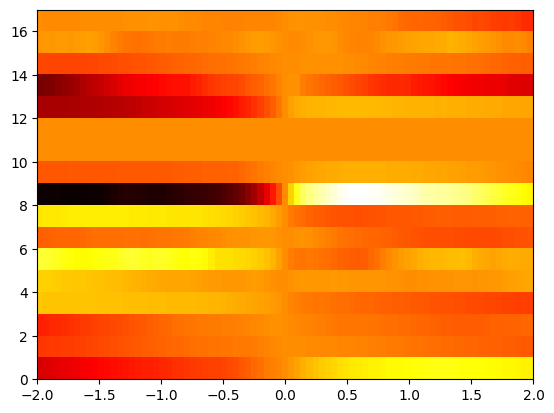

In [29]:
order = np.argsort(turn_units['turn_index'].values)

sta = sta_unwrap.copy()
zero_index = np.where(sta.t == 0)[0][0]
sta = sta - sta[zero_index, :]
# sta = sta[:, order]
plt.imshow(sta.d.T, aspect='auto', origin='lower', extent=[sta.t[0], sta.t[-1], 0, len(turn_units)], cmap='hot')

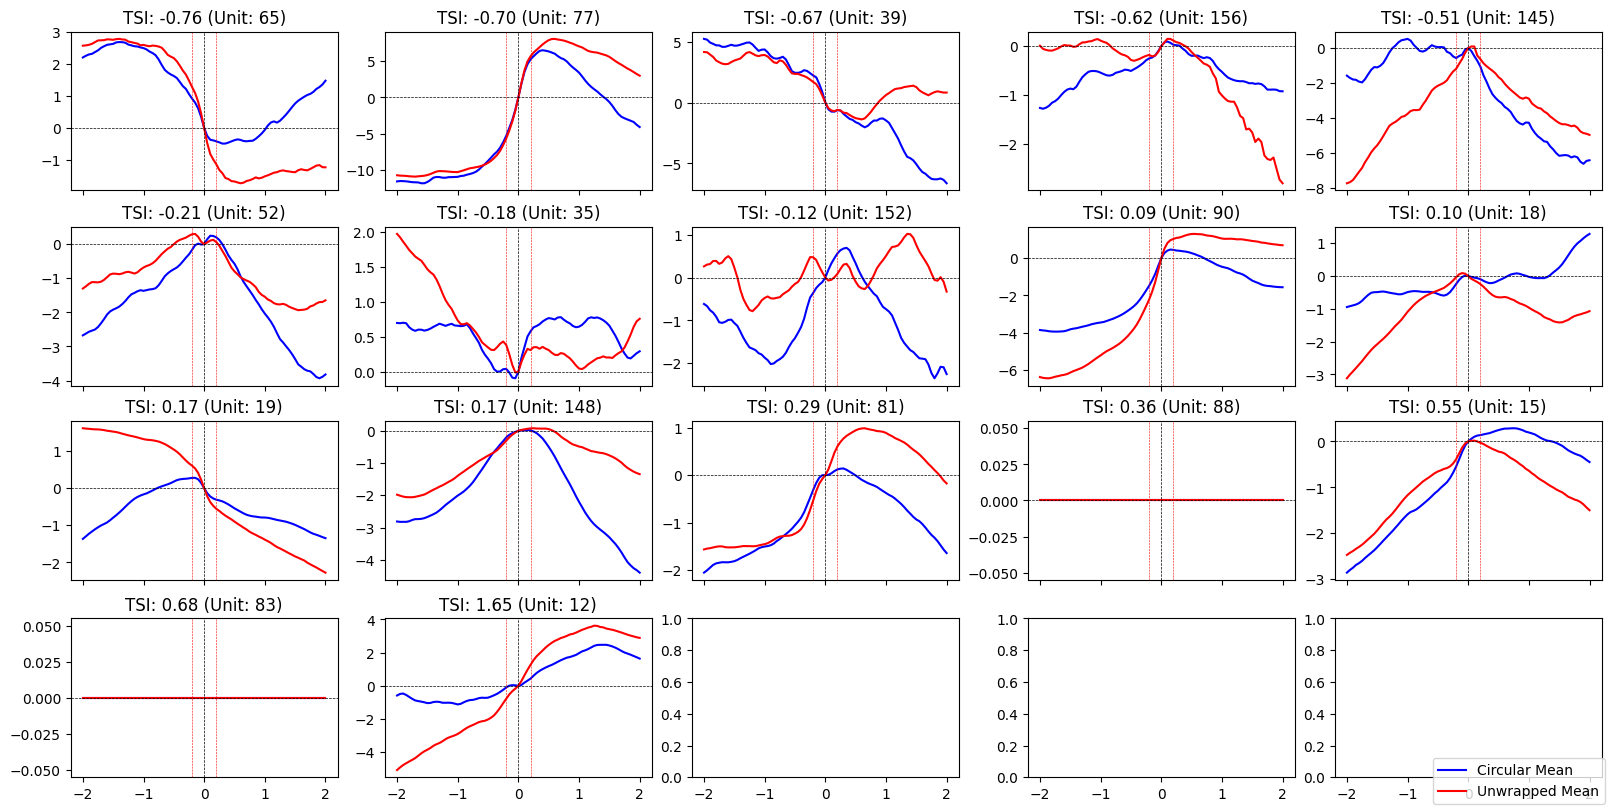

In [ ]:
f, axs = plot_sta(sta_cart, sta_unwrap, turn_units)
f.legend(["Circular Mean", "Unwrapped Mean"], loc='lower right')
plt.show(f)

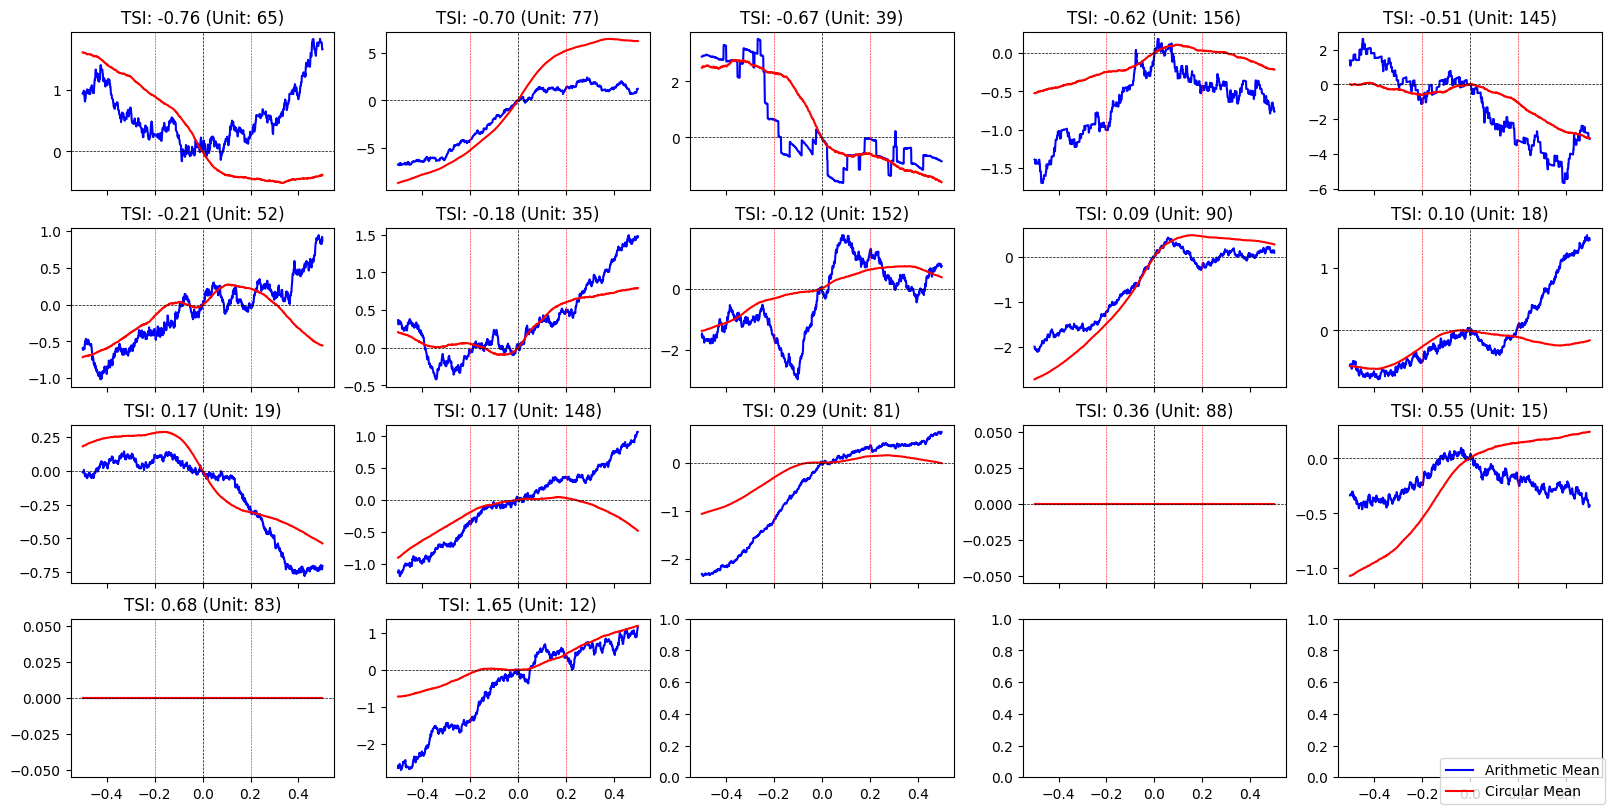

In [20]:
f, axs = plot_sta(sta, sta_cart, turn_units)
f.legend(["Arithmetic Mean", "Circular Mean"], loc='lower right')
plt.show(f)

### Visualize STA

In [6]:
def plot_sta(sta_awake, sta_nrem, turn_units):
    ncols = 5
    nrows = int(np.ceil(sta_awake.shape[1] / ncols))

    f, axs = plt.subplots(
        nrows, ncols,
        figsize=(16, 8),
        sharex=True,
        # sharey=True,
        constrained_layout=True,
        )

    order = np.argsort(turn_units['turn_index'].values)
    axs = axs.flatten()
    for i, idx in enumerate(order):
        uid = turn_units.index[idx].item()
        ax = axs[i]

        for sta, color in zip([sta_awake, sta_nrem], ['b', 'r']):
            zero_idx = np.where(sta.index == 0)[0].item()
            baseline = sta[zero_idx, :]
            sta_norm = sta - baseline
            ax.plot(sta_norm[:, idx], color=color)
        
        ax.set_title(f"TSI: {turn_units['turn_index'].values[idx]:.2f} (Unit: {uid})")
        
        ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
        ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax.axvline(0.2, color='r', linestyle='--', linewidth=0.4)
        ax.axvline(-0.2, color='r', linestyle='--', linewidth=0.4)

    return f, axs

In [6]:
save_dir = FIGURES_DIR
mv = "movement_var20"
subject_ids = ['99b', '107b']

for mouse_id in subject_ids:
    data_dir = INTERIM_DIR  / mv / mouse_id
    if not data_dir.exists():
        continue
    
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    sta_awake = nap.load_file(data_dir / "sta_awake.npz")
    sta_nrem = nap.load_file(data_dir / "sta_nrem_cont200.npz")

    plot_sta(sta_awake, sta_nrem, turn_units, mouse_id, save_dir)

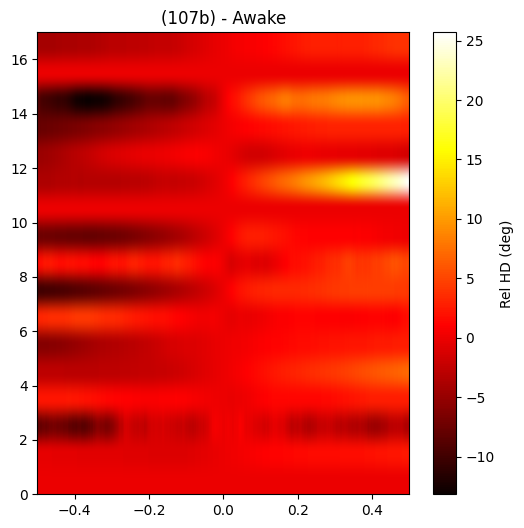

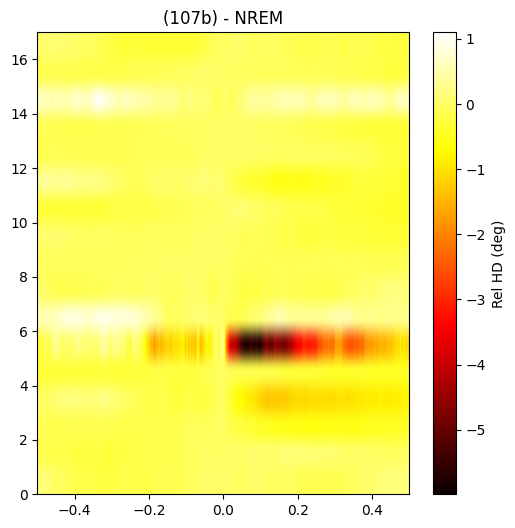

In [133]:
for sta in [sta_awake, sta_nrem]:
    zero_idx = np.where(sta.index == 0)[0].item()
    baseline = sta[zero_idx, :]
    sta_norm = sta - baseline
    plt.figure(figsize=(6, 6))
    im = plt.imshow(sta_norm.d[:, order].T, aspect='auto', origin='lower', extent=[sta_norm.index[0], sta_norm.index[-1], 0, sta_norm.shape[1]], cmap='hot')
    plt.colorbar(im, label='Rel HD (deg)')
    plt.title(f"({mouse_id}) - {'Awake' if sta is sta_awake else 'NREM'}")

### Turn amplitude

In [167]:
mv = "movement_var20"
subject_ids = ['99b', '107b']

sta_awake = []
sta_nrem = []
for mouse_id in subject_ids:
    data_dir = INTERIM_DIR  / mv / mouse_id
    if not data_dir.exists():
        continue

    sta_awake.append(nap.load_file(data_dir / "sta_awake.npz").d)
    sta_nrem.append(nap.load_file(data_dir / "sta_nrem.npz").d)

sta_awake = np.concatenate(sta_awake, axis=1)
sta_nrem = np.concatenate(sta_nrem, axis=1)
t = nap.load_file(data_dir / "sta_awake.npz").t

In [168]:
before_idx = np.where(t == -0.2)[0][0]
after_idx = np.where(t == 0.2)[0][0] + 1
awake_amp = sta_awake[after_idx, :] - sta_awake[before_idx, :]

turn_amps = []
for thresh in [0.02, 0.05, 0.2]:
    before_idx = np.where(t == -thresh)[0][0]
    after_idx = np.where(t == thresh)[0][0] + 1
    turn_amp = sta_nrem[after_idx, :] - sta_nrem[before_idx, :]
    turn_amps.append(turn_amp)
turn_amps = np.column_stack(turn_amps)

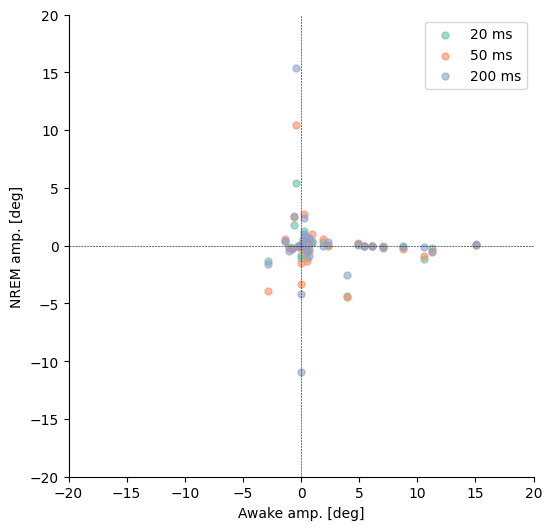

In [187]:
fig, ax = plt.subplots(figsize=(6, 6))

for i, thresh in enumerate([0.02, 0.05, 0.2]):
    ax.scatter(awake_amp, turn_amps[:, i], label=f"{(thresh * 1000):.0f} ms", color=cm(i), s=25, alpha=0.6)

ax.set_xlabel("Awake amp. [deg]")
ax.set_ylabel("NREM amp. [deg]")

ax.set_ylim(-20, 20)
ax.set_xlim(-20, 20)

ax.axhline(0, color='k', linestyle='--', linewidth=0.4)
ax.axvline(0, color='k', linestyle='--', linewidth=0.4)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.legend()